movie analyzer node
这部电影是周星驰的经典喜剧，讲述江南才子唐伯虎为追求华府丫鬟秋香，不惜卖身入府为奴，用各种无厘头手段和才华赢得美人芳心，最终抱得美人归的搞笑故事。

lyric producer node
（主歌）
桃花坞里藏不住心事，墨香染透青衫袖
为见你一面，甘愿折腰作小奴
笑骂皆成诗，荒唐里藏着真心
秋香啊，你可看见我眼底的星斗

（副歌）
世人笑我癫狂，我笑世人看不穿
泼墨挥毫间，写尽风流与痴缠
三笑姻缘定，不羡鸳鸯不羡仙
只愿此生，与你共画这人间



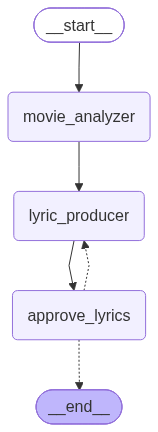


=== 结束流程 ===


In [5]:
from IPython.display import display, Image
from langgraph.types import Command

from src.user_graph import user_graph

config = {"configurable": {"thread_id": "1"}}

result = user_graph.invoke({"prompt": "唐伯虎点秋香"}, config=config)

while "__interrupt__" in result:
    # 阻塞程序，等待用户输入
    answer = input("你对生成的歌词满意吗？(y/n): ").strip()
    # 这里的answer是在下一次调用interupt的时候，会直接传入resume值（也就是恢复的时候）
    result = user_graph.invoke(Command(resume=answer), config=config)
    
display(
    Image(
        user_graph
        .get_graph(xray=True)
        .draw_mermaid_png()
    )
)
print("\n=== 结束流程 ===")